In [29]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from scipy.stats import randint
import pickle
import seaborn as sb

from data import get_data

In [30]:
data = get_data()
data['used_bikes'] = pd.to_numeric(data['used_bikes']) * 100
data['month'] = data['timestamp'].dt.month
data['day'] = data['timestamp'].dt.day
data['hour'] = data['timestamp'].dt.hour
data.drop(['batch_id', 'id', 'timestamp'], axis=1, inplace=True)
y = data['used_bikes']
X = data.drop('used_bikes', axis=1)

In [31]:
data.head()

,used_bikes,temperature,relative_humidity,apparent_temperature,is_day,surface_pressure,pressure_msl,precipitation,rain,snowfall,showers,cloud_cover,wind_speed,wind_direction,weather_code,month,day,hour
0,51.32,-5.5425,49,-10.524596,False,1007.821167,1014.400024,0.0,0.0,0.0,0.0,0,9.746631,274.236328,0,1,3,11
1,51.46,-6.2425,53,-11.055573,False,1008.598572,1015.200012,0.0,0.0,0.0,0.0,0,8.707238,262.875092,0,1,3,12
2,51.55,-5.7425,52,-10.650141,True,1009.604492,1016.200012,0.0,0.0,0.0,0.0,100,9.449572,252.255234,3,1,3,13
3,51.64,-4.1425,45,-9.299176,True,1009.445007,1016.000000,0.0,0.0,0.0,0.0,100,11.043261,289.025696,3,1,3,14
4,51.81,-2.1425,45,-7.358112,True,1007.903442,1014.400024,0.0,0.0,0.0,0.0,100,12.224107,283.627014,3,1,3,16


<Axes: >

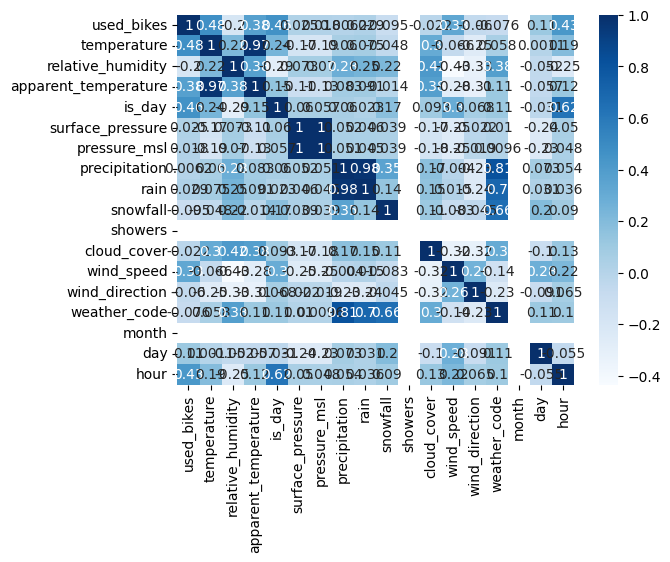

In [32]:
corr = data.corr()
sb.heatmap(corr, cmap="Blues", annot=True)

In [33]:
X = X.drop(['apparent_temperature', 'surface_pressure', 'rain', 'weather_code'], axis=1)
X_new = SelectKBest(f_regression, k=10).fit_transform(X, y)
selected_features = X.columns[SelectKBest(f_regression, k=10).fit(X, y).get_support()]
print(selected_features)

Index(['temperature', 'relative_humidity', 'is_day', 'pressure_msl',
       'snowfall', 'cloud_cover', 'wind_speed', 'wind_direction', 'day',
       'hour'],
      dtype='object')


In [40]:
X_new

array([[ -5.54250002,  49.        ,   0.        , ..., 274.23632812,
          3.        ,  11.        ],
       [ -6.24249983,  53.        ,   0.        , ..., 262.87509155,
          3.        ,  12.        ],
       [ -5.74249983,  52.        ,   1.        , ..., 252.25523376,
          3.        ,  13.        ],
       ...,
       [  0.40749997, 100.        ,   1.        , ...,  74.05453491,
         18.        ,  16.        ],
       [ -5.99249983,  35.        ,   1.        , ..., 266.68228149,
         20.        ,  20.        ],
       [ -5.99249983,  35.        ,   1.        , ..., 266.68228149,
         20.        ,  20.        ]], shape=(187, 10))

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size = 0.3, random_state=123)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred))
print("Linear Regression RMSE:", mean_squared_error(y_test, y_pred))

Linear Regression MAE: 0.6063278812790376
Linear Regression RMSE: 0.5988218822865562


In [36]:
rf = RandomForestRegressor(
    random_state=123,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [10, 20, 30, 50, 70],
    "max_depth": [None, 5, 7, 10, 20],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2", None, 1]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,               
    cv=3,
    scoring="neg_mean_squared_error",  
    random_state=123,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)
best = random_search.best_estimator_

print("Best parameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}


In [37]:
y_pred = best.predict(X_test)
print("Best Random Forest Regression MAE:", mean_absolute_error(y_test, y_pred))
print("Best Random Forest RMSE:", mean_squared_error(y_test, y_pred))

Best Random Forest Regression MAE: 0.4105419848864564
Best Random Forest RMSE: 0.26352685168159745


In [38]:
best.fit(X_new, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [ ]:
with open("model.pkl", "wb") as f:
    pickle.dump(best, f)

In [ ]:
with open("model.pkl", "rb") as f:
    model = pickle.load(f)

## pomysl 2

In [ ]:

def plot_multi(data, cols=None, spacing=.1, **kwargs):

    from pandas.plotting._matplotlib.style import get_standard_colors

    # Get default color style from pandas - can be changed to any other color list
    if cols is None: cols = data.columns
    if len(cols) == 0: return
    colors = get_standard_colors(num_colors=len(cols))

    # First axis
    ax = data.loc[:, cols[0]].plot(label=cols[0], color=colors[0], **kwargs)
    ax.set_ylabel(ylabel=cols[0])
    lines, labels = ax.get_legend_handles_labels()

    for n in range(1, len(cols)):
        # Multiple y-axes
        ax_new = ax.twinx()
        ax_new.spines['right'].set_position(('axes', 1 + spacing * (n - 1)))
        data.loc[:, cols[n]].plot(ax=ax_new, label=cols[n], color=colors[n % len(colors)], **kwargs)
        ax_new.set_ylabel(ylabel=cols[n])
        
        # Proper legend position
        line, label = ax_new.get_legend_handles_labels()
        lines += line
        labels += label

    ax.legend(lines, labels, loc=0)
    return ax


<Axes: ylabel='used_bikes'>

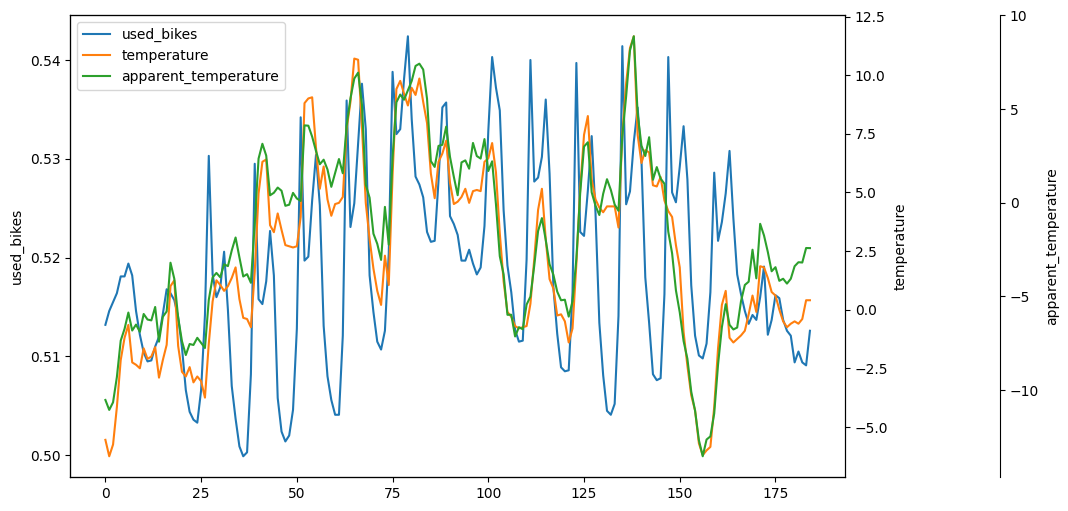

In [20]:
plot_multi(df, cols=['used_bikes', 'temperature', 'apparent_temperature'], spacing=0.2, figsize=(10,6))

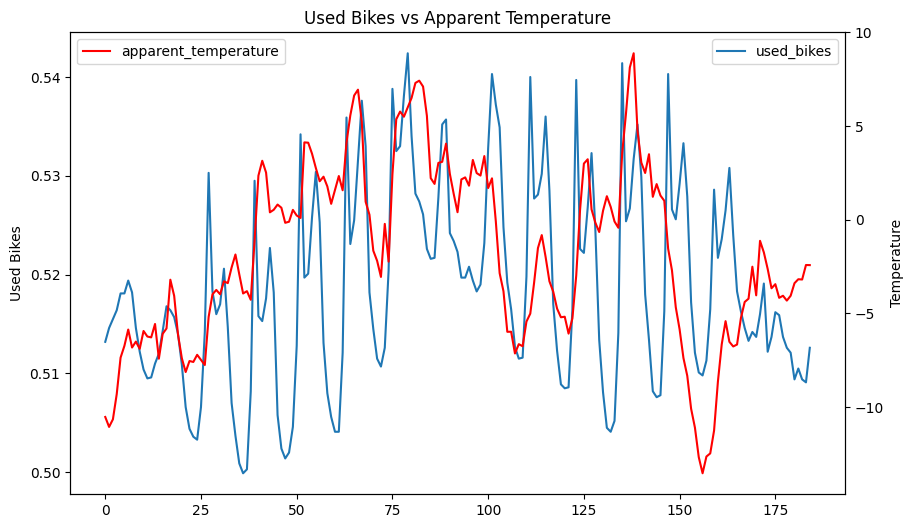

In [ ]:
import matplotlib.pyplot as plt

# df is your pandas DataFrame
# df.index should be a datetime index (or already sorted)

ax = df.plot(
    y="used_bikes",
    figsize=(10, 6),
    legend=True
)

ax.set_ylabel("Used Bikes")

# Create second y-axis
ax2 = ax.twinx()

df.plot(
    y="apparent_temperature",
    ax=ax2,
    legend=True,
    color = 'red'
)

# df.plot(y='temperature', ax=ax2, legend=True, color='green')

ax2.set_ylabel("Temperature")
plt.title("Used Bikes vs Apparent Temperature")
plt.show()
